# vLLM — инференс больших языковых моделей
Сравниваем наивный HuggingFace inference с vLLM: latency, throughput, tokens/s.

## 1. Импорты и конфигурация

In [6]:
import time

import matplotlib.pyplot as plt
import torch
from openai import OpenAI
from transformers import AutoModelForCausalLM, AutoTokenizer

# ── Device (CUDA имеет приоритет над MPS, если оба доступны) ─────────────────
DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
TORCH_DTYPE = torch.bfloat16 if DEVICE in ("cuda", "mps") else torch.float32

# ── Model ─────────────────────────────────────────────────────────────────────
MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"
PROMPT = "Объясни, что такое батчинг в mlserver, triton, за два предложения."

if DEVICE == "cuda":
    _cuda = torch.cuda.get_device_name(0)
    print(f"Device     : {DEVICE} ({_cuda})")
else:
    print(f"Device     : {DEVICE}")
print(f"Dtype      : {TORCH_DTYPE}")
print(f"Model      : {MODEL_ID}")

Device     : mps
Dtype      : torch.bfloat16
Model      : Qwen/Qwen2.5-0.5B-Instruct


## 2. Наивный HuggingFace inference
Загружаем модель напрямую — без очередей, батчинга и оптимизаций памяти.

In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

_load_kw = {"torch_dtype": TORCH_DTYPE}
if DEVICE == "cuda":
    # Раскладка весов на GPU без лишнего .to(); удобно при нескольких картах
    _load_kw["device_map"] = "auto"

model_hf = AutoModelForCausalLM.from_pretrained(MODEL_ID, **_load_kw)
if DEVICE != "cuda":
    model_hf = model_hf.to(DEVICE)
model_hf.eval()

print(f"Loaded {sum(p.numel() for p in model_hf.parameters()):,} params")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loaded 494,032,768 params


In [8]:
messages = [{"role": "user", "content": PROMPT}]
text = tokenizer.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
_hf_dev = next(model_hf.parameters()).device
inputs = tokenizer(text, return_tensors="pt").to(_hf_dev)

# ── Warmup ───────────────────────────────────────────────────────────────────
with torch.no_grad():
    _ = model_hf.generate(**inputs, max_new_tokens=10, do_sample=False)

# ── Timed run ────────────────────────────────────────────────────────────────
t0 = time.perf_counter()
with torch.no_grad():
    output = model_hf.generate(**inputs, max_new_tokens=200, do_sample=False)
hf_elapsed = time.perf_counter() - t0

n_input   = inputs["input_ids"].shape[1]
hf_tokens = output.shape[1] - n_input
hf_tps    = hf_tokens / hf_elapsed

hf_response = tokenizer.decode(output[0][n_input:], skip_special_tokens=True)

print(f"Response   : {hf_response}")
print(f"Tokens     : {hf_tokens}")
print(f"Time       : {hf_elapsed:.2f} s")
print(f"Speed      : {hf_tps:.1f} tok/s")

Response   : Батчинг в MLServer, Triton и других облачных сервисах машинного обучения - это методы обработки данных, которые используются для анализа и предсказания. Вот основные особенности каждого:

1. MLServer:
- Батчинг в MLServer - это процесс, который позволяет обрабатывать большие объемы данных с использованием сложных алгоритмов машинного обучения.
- Он использует многопоточность для эффективной работы и обеспечивает высокое производительность.
- Многие сервисы MLServer поддерживают батчинг в виде инструментов, таких как Python или Java.

2. Triton:
- Батчинг в Triton - это способ обработки данных с использованием искусственного интеллекта, который может анализировать и предсказать данные.
- Он использует сложные алгоритмы машинного обучения
Tokens     : 200
Time       : 2.34 s
Speed      : 85.4 tok/s


## 3. vLLM — OpenAI-совместимый API
Сервер заранее: **`./run_vllm_docker.sh`** (CPU, в т.ч. macOS) или **`./run_vllm_docker_gpu.sh`** (NVIDIA, Linux). Клиент — стандартный `openai`.

In [9]:
client = OpenAI(base_url="http://localhost:8000/v1", api_key="dummy")

# ── Warmup ───────────────────────────────────────────────────────────────────
client.chat.completions.create(
    model=MODEL_ID,
    messages=[{"role": "user", "content": "hi"}],
    max_tokens=5,
)

# ── Timed run ────────────────────────────────────────────────────────────────
t0 = time.perf_counter()
response = client.chat.completions.create(
    model=MODEL_ID,
    messages=[{"role": "user", "content": PROMPT}],
    max_tokens=200,
    temperature=0.0,
)
vllm_elapsed = time.perf_counter() - t0

vllm_tokens   = response.usage.completion_tokens
vllm_tps      = vllm_tokens / vllm_elapsed
vllm_response = response.choices[0].message.content

print(f"Response   : {vllm_response}")
print(f"Tokens     : {vllm_tokens}")
print(f"Time       : {vllm_elapsed:.2f} s")
print(f"Speed      : {vllm_tps:.1f} tok/s")

Response   : Батчинг в MLServer, Triton и других облачных сервисах машинного обучения - это методы обработки данных, которые используются для анализа и предсказания. Вот основные особенности каждого:

1. MLServer:
- Батчинг в MLServer - это процесс, который позволяет обрабатывать большие объемы данных с использованием сложных алгоритмов машинного обучения.
- Он использует многопоточность для обеспечения быстрого выполнения запросов и обновлений данных.
- Батчи могут быть отслеживаемыми или неотслеживаемыми, зависящими от того, как они будут использованы.

2. Triton:
- Батчинг в Triton - это способ обработки данных с использованием искусственного интеллекта, который может анализировать и предсказать события.
- Он использует слож
Tokens     : 200
Time       : 17.88 s
Speed      : 11.2 tok/s


## 4. Сравнение

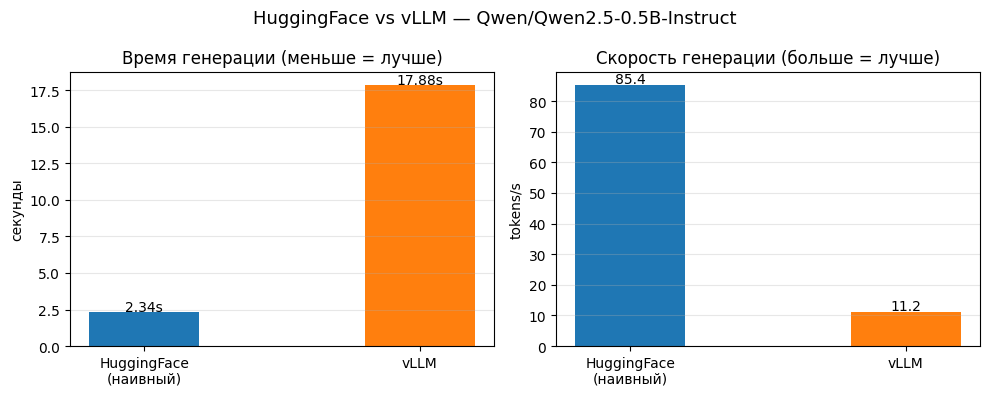


vLLM speedup: 0.1x


In [10]:
labels   = ["HuggingFace\n(наивный)", "vLLM"]
times    = [hf_elapsed, vllm_elapsed]
speeds   = [hf_tps, vllm_tps]
colors   = ["tab:blue", "tab:orange"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.bar(labels, times, color=colors, width=0.4)
ax1.set(title="Время генерации (меньше = лучше)", ylabel="секунды")
ax1.grid(axis="y", alpha=0.3)
for i, v in enumerate(times):
    ax1.text(i, v + 0.05, f"{v:.2f}s", ha="center", fontsize=10)

ax2.bar(labels, speeds, color=colors, width=0.4)
ax2.set(title="Скорость генерации (больше = лучше)", ylabel="tokens/s")
ax2.grid(axis="y", alpha=0.3)
for i, v in enumerate(speeds):
    ax2.text(i, v + 0.5, f"{v:.1f}", ha="center", fontsize=10)

plt.suptitle(f"HuggingFace vs vLLM — {MODEL_ID}", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nvLLM speedup: {vllm_tps / hf_tps:.1f}x")